# Tarea 1
## Adquisición y preparación de datos: API o Web Scraping

# Introducción a Ciencias de Datos
#### Fecha: 22-Junio-2026


# Desarrollo



## Uso de API pygbif para obtención de registro de especie Alstroemeria pulchra en Chile

### Introducción

Global Biodiversity Information Facility es una iniciativa intergubernamental para registrar y clasificar información de seres vivos en su inmensa diversidad.

En Chile, la iniciativa se encuentra respaldada por el Ministerio del Medio Ambiente:

https://gbifchile.mma.gob.cl/

Para una referencia rápida sobre el beneficio del uso de GBIF para el estudio de biodiversidad:

https://www.youtube.com/watch?v=HvS6sRVZbHo&t=7s




____

Desde el punto de la colección de datos, existen múltiples formas de obtener información desde GBIF: En primer lugar, consultas Web con descarga. Por último, a través de APIs para interactuar en lenguajes de programación como rbif, pygbif y Java.
Para el presente trabajo, se ha optado por trabajar a partir de la librería de python **pygbif**

La librería contiene módulos que permiten obtener informaciones tales como:


```
# occurences()
```
Registros compartidos por usuarios de diversas bases de datos reunidas en GBIF. Contempla tanto registros institucionales, como registros de ciencia ciudadana, como por ejemplo la plataforma *iNaturalist*, una popular plataforma digital con más de 300 millones de registros a nivel mundial.


```
# species()
```
Dimensión taxonómica de referencia para GBIF.

```
# maps()
```
Registros geoespaciales.
_____


Para una guía de uso general de pygbif:

* https://pygbif.readthedocs.io/en/latest/index.html

Para la comprensión del modelo taxonómico y atributos de la dimensión *species*:

* https://techdocs.gbif.org/en/data-use/download-formats
* https://techdocs.gbif.org/en/data-use/download-formats#species-list




## Código de Uso:



Si bien el acceso a la información contenida en GBIF es de libre acceso, deben tenerse en cuenta las obligaciones individuales de un usuario de estos datos, al utilizar el trabajo de otros.

### Reflexión ética sobre permisos

Cada registro contiene una licencia y, por lo tanto, una política de uso acorde. Para propósitos de publicación y manipulación de datos contenidos, es recomendable ceñirse a los líneamiento establecidos por GBIF en:

* https://www.gbif.org/citation-guidelines

Durante el desarrollo de este ejercicio, se validan y consideran datos con contenido licenciados bajo Creative Commons, un tipo de licencia que permite el uso de su información sin fines comerciales. Además, durante el desarrollo del ejercicio, se especifica la ruta de acceso y se cita su fuente de acuerdo al lineamiento de GBIF.

## Objetivo: Tasas de registros estacionales de Alstroemerias




La [Ficha de antecedentes de la especie](https://clasificacionespecies.mma.gob.cl/wp-content/uploads/2019/10/Alstroemeria_pulchra.pdf)(2012) y la [Nómina de especies según estado de conservación](https://clasificacionespecies.mma.gob.cl/wp-content/uploads/2026/06/NominaDeEspecies_SegunEstadoConservacion-Chile_actualizado_20mProcesoRCE_8junio2026.xlsx) del Ministerio del medioambiente (Decreto Categoría Vigente DS2013 MMA), reconocen dos subespecies: *ssp. pulchra* y *ssp. lavandulacea*, con distintos categorías de clasificación de riesgo: preocupación menor(LC) para ssp. pulchra y En peligro(EN) para ssp.lavandulacea.

Georeferenciar los registros de la especie y conocer su estacionalidad, comporta un beneficio para un plan de seguimiento de la especie.

El objetivo de este trabajo es puramente ejemplar, para establecer un método de conexión estable a los registros de una o más especies determinadas, en este caso *Alstroemeria pulchra*, mediante librerías de python y una conexión autenticada a la base de ocurrencias de GBIF.



## Dependencias

En primer lugar, es necesario resolver las dependencias de librerías requeridas con la instalación de:


```
# !pip install pygbif
```



In [1]:
!pip install pygbif

A continuación, importamos las librerías necesarias

In [2]:
import pandas as pd ## manipulación de dataframes
from pygbif import occurrences as occ ## módulo de ocurrencias de GBIF
from pygbif import species ## módulo de especies GBIF

import matplotlib.pyplot as plt ## visualización de registros
import os ## permite la conexión autenticada
import requests


###

### Políticas de acceso a ocurrencias de GBIF

El módulo de ocurrencias cuenta con distintos tipos de solicitud de información. Dependiendo de la necesidad y de la cantidad de datos, GBIF disponibiliza **ocurrences.get()** para consultas individuales y limitadas.


El módulo de descargas de información, a partir de consultas estructuradas, requiere la autenticación de un usuario y sus credenciales. Una nueva cuenta puede ser creada en:
https://www.gbif.org/user/register

Únicamente para efectos de evaluación, se ha creado un usuario con el correo institucional:



```
 os.environ['GBIF_USER']="user"
 os.environ['GBIF_PWD']="passwd"
 os.environ['GBIF_EMAIL']="user@estudiante.uc.cl"
```



In [3]:
# @title Credenciales {"display-mode":"form"}
os.environ['GBIF_USER']="lmenzelr"
os.environ['GBIF_PWD']= ""
os.environ['GBIF_EMAIL']="lmenzelr@estudiante.uc.cl"

## Adquisición y estrategia de datos.

Con el comando

```
# species.name_backbone()
```
hacemos una búsqueda de los datos de la especie, según **scientificName**.


In [4]:
search_ = species.name_backbone(scientificName="Alstroemeria pulchra", kingdom="Plantae")


Extraemos la llave.

In [5]:
taxkey = search_['usage']['key']
print(taxkey)

2753903


Con el módulo de búsqueda
```
occ.search
```
 es posible validar el tipo de información disponible, a partir de un taxonKey, que identifica la especie requerida.

In [6]:
occ1 = occ.search(taxonKey = taxkey,limit=1,country='CL')

Imprimir el resultado del diccionario nos permite una exploración inicial del tipo de datos disponibles en la base de datos.

In [7]:
for k,v in occ1['results'][0].items():
  print(f'{k}: {v}')

key: 6159467125
datasetKey: 50c9509d-22c7-4a22-a47d-8c48425ef4a7
publishingOrgKey: 28eb1a3f-1c15-4a95-931a-4af90ecb574d
installationKey: 997448a8-f762-11e1-a439-00145eb45e9a
hostingOrganizationKey: 28eb1a3f-1c15-4a95-931a-4af90ecb574d
publishingCountry: US
protocol: DWC_ARCHIVE
lastCrawled: 2026-06-05T18:15:48.952+00:00
lastParsed: 2026-06-12T02:09:03.850+00:00
crawlId: 595
extensions: {'http://rs.gbif.org/terms/1.0/Multimedia': [{'http://purl.org/dc/terms/license': 'https://creativecommons.org/licenses/by-nc/4.0/', 'http://purl.org/dc/terms/created': '2026-01-04T15:41:17-08:00', 'http://purl.org/dc/terms/format': 'image/jpeg', 'http://purl.org/dc/terms/identifier': 'https://inaturalist-open-data.s3.amazonaws.com/photos/615546564/original.jpg', 'http://purl.org/dc/terms/rightsHolder': 'Gábor Keresztes', 'http://rs.tdwg.org/dwc/terms/catalogNumber': '615546564', 'http://purl.org/dc/terms/type': 'StillImage', 'http://purl.org/dc/terms/creator': 'Gábor Keresztes', 'http://purl.org/dc/term

Las consultas de búsqueda se encuentran limitadas a la búsqueda de registros específicos. Para el ejemplo actual, la forma de consulta inicial se establece con


```
# occ.get(key=key_id)
```
 #### AVISO
 No confundir taxonKey y key. El primero hace referencia a la llave de especie, mientras el segundo hace referencia al identificador del registro.


In [8]:
occ.get(key= occ1['results'][0]['key'])

{'key': 6159467125,
 'datasetKey': '50c9509d-22c7-4a22-a47d-8c48425ef4a7',
 'publishingOrgKey': '28eb1a3f-1c15-4a95-931a-4af90ecb574d',
 'installationKey': '997448a8-f762-11e1-a439-00145eb45e9a',
 'hostingOrganizationKey': '28eb1a3f-1c15-4a95-931a-4af90ecb574d',
 'publishingCountry': 'US',
 'protocol': 'DWC_ARCHIVE',
 'lastCrawled': '2026-06-05T18:15:48.952+00:00',
 'lastParsed': '2026-06-12T02:09:03.850+00:00',
 'crawlId': 595,
 'extensions': {'http://rs.gbif.org/terms/1.0/Multimedia': [{'http://purl.org/dc/terms/license': 'https://creativecommons.org/licenses/by-nc/4.0/',
    'http://purl.org/dc/terms/created': '2026-01-04T15:41:17-08:00',
    'http://purl.org/dc/terms/format': 'image/jpeg',
    'http://purl.org/dc/terms/identifier': 'https://inaturalist-open-data.s3.amazonaws.com/photos/615546564/original.jpg',
    'http://purl.org/dc/terms/rightsHolder': 'Gábor Keresztes',
    'http://rs.tdwg.org/dwc/terms/catalogNumber': '615546564',
    'http://purl.org/dc/terms/type': 'StillImag

## Extracción de datos

Como se menciona previamente, el acceso a consultas estructuradas requiere autenticación. Una vez establecida, es posible filtrar la consulta según los parámetros deseados utilizando


```
# occ.download()
```

El resultado de la consulta, devolverá el mensaje de creación del enlace de descarga, el cual se alojará temporalmente en una URL pública, la que puede ser consultada por el usuario solicitante en:

https://www.gbif.org/user/download


### IMPORTANTE
las dos siguientes celdas de código se encuentran comentadas ya que las credenciales han sido removidas, por razones de seguridad. Para poder ejecutar esta consulta y la siguiente, es necesario utilizar un usuario válido en GBIF.

```
 os.environ['GBIF_USER']="user"
 os.environ['GBIF_PWD']="passwd"
 os.environ['GBIF_EMAIL']="user@estudiante.uc.cl"
```



In [9]:
#occ.download(['taxonKey = 2753903', 'country = CL'])

Para más información visite:

* https://techdocs.gbif.org/en/openapi/v1/occurrence


Alternativamente, **occ.download** permite la creación de consultas tipo SQL mediante


```
# occ.download_sql("SQL like query FROM occurrence  WHERE condition")
```



In [10]:
#occ.download_sql("SELECT gbifid,publishingCountry FROM occurrence WHERE publishingCountry='CL' AND taxonKey=2753903")

Para el caso de este ejercicio, se ha generado una URL de consulta previamente, debido a que el **tiempo de descarga prometido** por el proveedor varía entre **15 min a 3 horas**.

El link de acceso para este ejercicio se encuentra disponible hasta el 22 de Diciembre de 2026.

Licencia: **CC BY-NC 4.0**

 * GBIF.org (22 June 2026) GBIF Occurrence Download https://doi.org/10.15468/dl.gwxuez


Siguiendo los pasos anteriores, podemos crear una ahora una consulta tipo get asincrónica, utilizando


```
# occ.download_get(hash)
```



configuramos la consulta **download_get** a partir de la información disponible en:

https://www.gbif.org/occurrence/download/0073548-260519110011954

In [11]:
x = occ.download_get('0073548-260519110011954')

INFO:Download file size: 55287 bytes
INFO:On disk at ./0073548-260519110011954.zip


In [12]:
print(x)

{'path': './0073548-260519110011954.zip', 'size': 55287, 'key': '0073548-260519110011954'}


Una vez establecida la conexión, creamos una variable *path* para poblar nuestro dataframe a partir del archivo **.zip** disponible.

In [13]:
url = x['path']

In [14]:
#url = 'https://api.gbif.org/v1/occurrence/download/request/0073548-260519110011954.zip'

Configuramos el método de lectura de CSV, con argumentos para indicar que el archivo fuente viene comprimido y declaramos separador.


In [15]:
df = pd.read_csv(url,compression='zip',sep='\t') ## para establecer esta conexión, se ha consultado un motor de IA sólamente para identificar la forma óptima de conectar path por error de lectura.

## Limpieza y validación

Partimos identificando la totalidad de información existente

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Data columns (total 50 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   gbifID                            751 non-null    int64  
 1   datasetKey                        751 non-null    object 
 2   occurrenceID                      729 non-null    object 
 3   kingdom                           751 non-null    object 
 4   phylum                            751 non-null    object 
 5   class                             751 non-null    object 
 6   order                             751 non-null    object 
 7   family                            751 non-null    object 
 8   genus                             751 non-null    object 
 9   species                           751 non-null    object 
 10  infraspecificEpithet              170 non-null    object 
 11  taxonRank                         751 non-null    object 
 12  scientif

In [17]:
df.shape

(751, 50)

Ya que nuestra consulta cuenta con 50 columnas disponibles, lo primero que haremos será identificar aquellas columnas que contengan información relevante para nuestro propósito.

In [18]:
filtered_columns = ['gbifID','occurrenceID','eventDate','month','year','license','stateProvince','decimalLatitude','decimalLongitude']
df_filtered = df[filtered_columns]

In [19]:
df_filtered.sample(5)

,gbifID,occurrenceID,eventDate,month,year,license,stateProvince,decimalLatitude,decimalLongitude
671,3328141553,https://www.inaturalist.org/observations/87149498,2020-11-29T14:38:46,11.0,2020.0,CC_BY_NC_4_0,Valparaíso,-32.765147,-71.111197
490,4403281135,UCh:AGUCH:33283,1997-10-25,10.0,1997.0,CC_BY_NC_4_0,Región Metropolitana de Santiago,-33.756545,-70.938084
291,4976358078,https://www.inaturalist.org/observations/24941...,2024-10-26T10:03:38,10.0,2024.0,CC_BY_NC_4_0,Libertador General Bernardo O'Higgins,-34.517053,-71.081305
167,5893024433,https://www.inaturalist.org/observations/32351...,2025-10-26T10:35:49,10.0,2025.0,CC0_1_0,Valparaíso,-33.041096,-71.551493
99,6159299168,https://www.inaturalist.org/observations/31344...,2023-10-07T13:48:26,10.0,2023.0,CC_BY_4_0,Valparaíso,-32.237665,-71.521285


Hacemos una validación para confirmar que estamos trabajando con datos de acceso permitido para investigación no comercial *Creative Commons*.

In [20]:
df_filtered['license'].unique()

array(['CC_BY_4_0', 'CC0', 'CC_BY_NC_4_0', 'CC0_1_0'], dtype=object)

Volvemos a validar la integridad de los datos resultantes.

In [21]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gbifID            751 non-null    int64  
 1   occurrenceID      729 non-null    object 
 2   eventDate         719 non-null    object 
 3   month             716 non-null    float64
 4   year              719 non-null    float64
 5   license           751 non-null    object 
 6   stateProvince     712 non-null    object 
 7   decimalLatitude   690 non-null    float64
 8   decimalLongitude  690 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 52.9+ KB


Ya que los registros de vectores de longitud y latitud son relevantes para análisis geoespacial, filtramos aquellos registros que no cuentan con dicha información, así como otros registros que puedan entorpecer el manejo eficiente de transformaciones por datos *nan*.

In [22]:
df_filtered.dropna(inplace=True)

C:\Users\ganymede\AppData\Local\Temp\ipykernel_10132\208647654.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.dropna(inplace=True)


Como resultado, obtenemos un objeto de tamaño.

In [23]:
df_filtered.shape

(681, 9)

Finalmente, convertimos los valores de mes y año, requeridos para análisis estacional, a formato *int* para normalizar su uso.

In [24]:
df_filtered['month'] = df_filtered['month'].astype(int)
df_filtered['year'] = df_filtered['year'].astype(int)

C:\Users\ganymede\AppData\Local\Temp\ipykernel_10132\670888251.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['month'] = df_filtered['month'].astype(int)
C:\Users\ganymede\AppData\Local\Temp\ipykernel_10132\670888251.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['year'] = df_filtered['year'].astype(int)


In [25]:
df_filtered.sample(5)

,gbifID,occurrenceID,eventDate,month,year,license,stateProvince,decimalLatitude,decimalLongitude
713,2603391648,https://www.inaturalist.org/observations/42016361,2016-10-08T18:20,10,2016,CC_BY_NC_4_0,Coquimbo,-31.262581,-71.160878
701,2846602141,VALPL_PLV:1305,1985-11-02,11,1985,CC_BY_4_0,Región de Valparaíso,-33.068056,-71.557500
304,4936562304,https://www.inaturalist.org/observations/13993...,2022-10-23T21:20,10,2022,CC_BY_NC_4_0,Valparaíso,-32.907664,-71.060427
691,2898443580,https://www.inaturalist.org/observations/62055999,2020-10-01T16:55,10,2020,CC_BY_NC_4_0,Valparaíso,-32.240233,-71.520672
246,5133541620,https://www.inaturalist.org/observations/25037...,2024-11-02T14:22,11,2024,CC_BY_NC_4_0,Valparaíso,-32.916161,-71.035608


## Diccionario de datos

Una vez reducidos y normalizados los datos de trabajo, insertamos la definición formal obtenida desde la documentación fuente. La mayoría de los términos están definidos de acuerdo al Darwin Core standard (**dwc**)
* https://techdocs.gbif.org/en/data-use/download-formats
* https://dwc.tdwg.org/list/#dwc_catalogNumber



---


0.   **gbifID** *string not null*. Llave única de GBIF para la ocurrencia.
1.   **occurenceID** *string*. Un identificador para la dwc(Darwin Core Standard). En ausencia de un identificador único global, construye uno desde la combinación de identificadores en el registro lo más parecido a la construcción de *dwc:OccurrenceID*
2.   **eventDate** *string*. Fecha y hora durante la cual ocurrió un Evento. Para ocurrencias, es la fecha cuando el evento fue registrado. No ajustable para un tiempo en contexto geológico.
3.   **month** *integer*. El entero delmes en el cal el Evento ocurrió.
4.   **year** *integer*. Los cuatro dígitos del año en el cual un evento ocurrió. de acuerdo al Calendario de Era Común.
5.   **license** *string*. Documento legal que otorga permiso oficial para el uso de la ocurrencia.
6.   **stateProvince** *string*. El nombre de la región administrativa más pequeña que un país (estado, provincia, cantón, departamento, región, etc) en el cual dcterms:Location ocurrió.
7.   **decimalLatitude** *double*. Latitud geográfica (en grados decimales, usando el datum WGS84) del centro geográfico de la ubicación de la referencia
8.   **decimalLongitude** *double*. Longitud geográfica (en grados decimales, usando el datum WGS84) del centro geográfico de la ubicación de la referencia







## Resumen final

El presente trabajo ha establecido una conexión hacia el ambiente de GBIF de manera que puedan adquirirse datos sobre registros de biodiversidad, de acuerdo con las reglas de uso del proveedor.

A continuación, se incluye un gráfico que ordena los registros en histograma de meses y años.

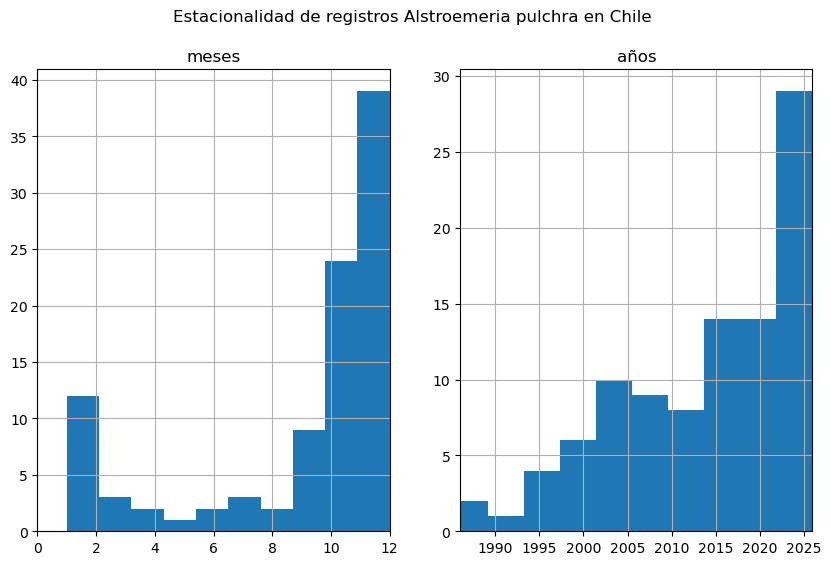

In [26]:
import matplotlib.pyplot as plt
to_plot = df_filtered.groupby(['month','year'])['gbifID'].count().reset_index()
to_plot

fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(10,6))
ax1 = to_plot['month'].hist(ax=ax[0])
ax2 = to_plot['year'].hist(ax=ax[1])
ax1.set_xlim(0,12)
ax2.set_xlim(1986,2026)
fig.suptitle('Estacionalidad de registros Alstroemeria pulchra en Chile')
ax1.set_title('meses')
ax2.set_title('años')

plt.show()

El gráfico anterior ejemplifica que, de forma agregada, los registros se encuentran concentrados sobre el final de primavera e inicios de verano, así como una tendencia creciente de registros el último año.
Combinar este tipo de información con su localización puede aportar a la planificación de nuevas observaciones a partir de las ya registradas. Se podría también estudiar si existe una variación a lo largo de los años en la tendencia de observación.

Por otra parte, el estudio comparado de los registros según geolocalización podría permitir identificar zonas donde hubo registros en el pasado, pero que han perdido trazabilidad en el tiempo, dirigiendo un esfuerzo en sitio a realizar observaciones que permitan identificar el estado actual de conservación de la especie.

Adicionalmente, ha quedado fuera de alcance de este trabajo, la exploración de datos de tipo imagen, el cual es altamente relevante para investigación en sistemas de clasificación con técnicas de Machine Learning, y que podría ayudar a caracterizar oportunidades de reclasificación o estudios focalizados de la subespecie *Alstroemeria pulchra ssp. lavandulacea*, la cual se encuentra actualmente en peligro.